# CNN Layercam Analysis

## Introduction
Convulutional Neural Networks (CNN) are a type of neural network specifically designed for image data. Compared to other types of neural networks, CNN's are better at handling images because they can detect patterns such as edges, shapes, and textures. This makes CNN's quite effective at classifiying images. Even though CNN's perform well, they can be difficult to understand. This analysis shows how the network determines it's classification.

This report contains the predictions of 3 different classes, both positive and negative. A LayerCam is used to show what influences the model prediction the most.
## Method
In this report a pre-trained CNN model (ResNet18) is used (with default weights) trained on the ImageNet dataset to classify images into 1000 predefined classes without additional training. Images used were preprocessed using the standard transformations (resize and normalize) before the model prediction. The model prediction outputs, so called logits, which are then converted to probabilities using softmax to determine the most likely class. To analyze which part of the image influenced the model predictions a Class Activation Map (CAM) (with layer set to default) was used.

In [16]:
import importlib
import Cnn
importlib.reload(Cnn)
import torch
import matplotlib.pyplot as plt

model, weights = Cnn.load_model()
classes = {
    "golden_retriever": {
        "positive": "data/golden_positive.jpeg",
        "negative": "data/golden_negative.jpeg"
    },
    "airliner": {
        "positive": "data/airplane_positive.jpeg",
        "negative": "data/airplane_negative.jpeg"
    },
    "electric_guitar": {
        "positive": "data/guitar_positive.jpeg",
        "negative": "data/guitar_negative.jpeg"
    }
}


## Class 1 - Golden Retriever
The first class contains images of a Golden retriever (left) and a Labrador retriever (right) and is classified correctly. The attribution maps shows how the model focuses on the head and face of the dogs and filters out the background quite well. To the untrained human eye these dog breeds looks very similar and could be hard to differentiate between. The model does a good job using the small differences such as facial structure, fur characteristics and color to identify the correct classes.

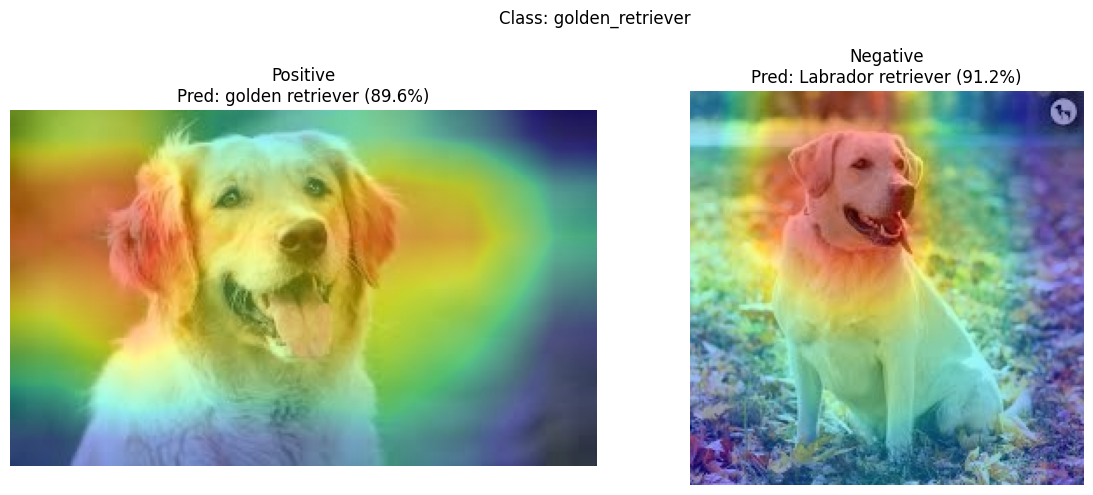

In [17]:


pos, neg = Cnn.analyze_class(model, weights, "golden_retriever", classes)
Cnn.plot_class_results(pos, neg, "golden_retriever")

## Class 2 - Airplane
The second class includes an image of an airplane (left) and an image of a space shuttle (right). Both the positive and negative examples are classified correctly. In both images the background is largely ignored, indicating that the model focuses on the correct object for identification. In the positive example the whole body of the airplane is in focus, whereas in the negative example the model focuses on the wings and tail structure more. The biggest differences between the images are: the plane has a longer body, a larger wingspan and thrusters beneath the wings. The model identifies the key characteristics well and is certain of the prediction.

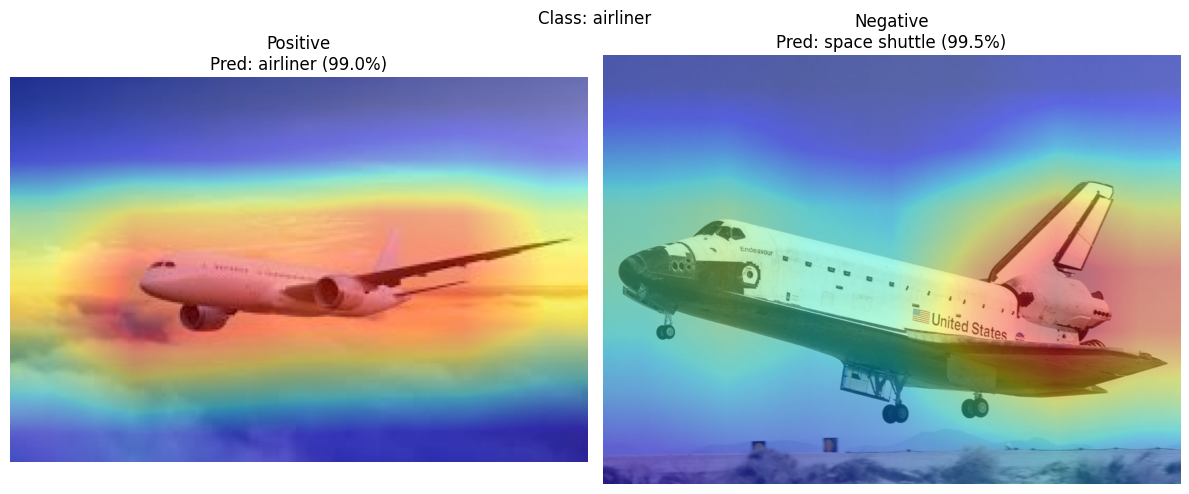

In [18]:
pos, neg = Cnn.analyze_class(model, weights, "airliner", classes)
Cnn.plot_class_results(pos, neg, "airliner")

## Class 3 - Electric guitar
The third class images are of an electric guitar and a violin. In the positive image the focus of the model is largely on the body and the neck of the guitar with the main focus being on the mid body and pickups. This shows that the overall shape is important but the main structural feature like the pickups helps the model distinguish between an electric guitar and a violin. In the negative image the model predicts violin correctly, and again the shape is the main determining factor. The center of the violin have a very narrow "waist" compared to the guitar, a shorter neck, and no pickups.

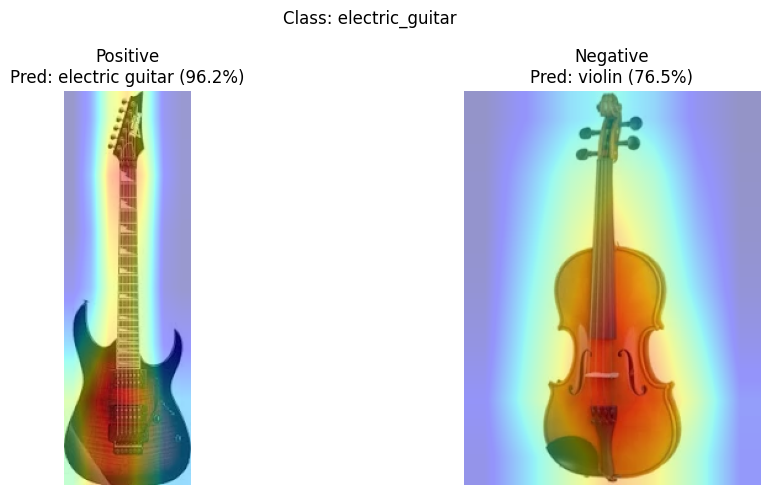

In [20]:
pos, neg = Cnn.analyze_class(model, weights, "electric_guitar", classes)
Cnn.plot_class_results(pos, neg, "electric_guitar")

## Discussion
Below you can se the different logits score on the positive example in class 3 - Electric guitar. The top 5 highest points were all connected to string instruments with acoustic guitar, banjo and cello being relatives to the electric guitar. These instruments are similiar in shape, which indicates the model considers several related classes before narrowing it down to its final prediction. An interesting thing is that the model also gave a high logits score to a pick. A pick is used to play some string instrument but isnt similar in shape which is often the determining factor on CNN models. This suggest that the training data could have included pictures with both guitars and picks in it and that the model has learned that images that looks like this often also contain something that looks like a pick.

In [21]:

logits = pos["logits"]
top_logits = torch.topk(logits, k=5)

for val, idx in zip(top_logits.values, top_logits.indices):
    print(f"{weights.meta['categories'][idx.item()]}: {val.item():.4f}")

electric guitar: 20.8107
acoustic guitar: 17.4372
banjo: 15.5048
pick: 12.1966
cello: 9.2595
